# 1-13. Maclaurin and Taylor Series


## Problems 1 through 4: Binomial Series

1. Use the ratio test to show that a binomial series converges for $|x|<1$.

2. Show that the binomial coefficients

$$
\binom{-1}{n}=(-1)^n.
$$

3. Show that if $p$ is a positive integer, then $\binom{p}{n}=0$ when $n>p$, so

$$
(1+x)^p=\sum_{n=0}^{p}\binom{p}{n}x^n
$$

is just a sum of $p+1$ terms, from $n=0$ to $n=p$. For example, $(1+x)^2$ has 3 terms, $(1+x)^3$ has 4 terms, etc. This is just the familiar binomial theorem.

4. Write the Maclaurin series for $1/\sqrt{1+x}$ in $\sum$ form using the binomial coefficient notation. Then find a formula for the binomial coefficients in terms of $n$ as we did in Example 2 above.


<a id="problem-1"></a>

### Problem 1. Ratio Test for the Binomial Series

For the binomial series, let

$$
a_n=\binom{p}{n} x^n.
$$

Then

$$
\left|\frac{a_{n+1}}{a_n}\right|
=\left|\frac{p-n}{n+1}x\right|.
$$

As $n\to\infty$,

$$
\left|\frac{p-n}{n+1}\right|\to 1,
$$

so

$$
\lim_{n\to\infty}\left|\frac{a_{n+1}}{a_n}\right|=|x|.
$$

By the ratio test, the binomial series converges when

$$
|x|<1.
$$


<a id="problem-2"></a>

### Problem 2. Coefficients for $p=-1$

Using the definition of the generalized binomial coefficient,

$$
\binom{-1}{n}
=\frac{(-1)(-2)(-3)\cdots(-n)}{n!}.
$$

The numerator is

$$
(-1)^n(1\cdot 2\cdot 3\cdots n)=(-1)^n n!,
$$

so

$$
\binom{-1}{n}=\frac{(-1)^n n!}{n!}=(-1)^n.
$$

Thus

$$
(1+x)^{-1}=\sum_{n=0}^{\infty}(-1)^n x^n,
\qquad |x|<1.
$$


<a id="problem-3"></a>

### Problem 3. Terminating Binomial Series

If $p$ is a positive integer, then for $n>p$, the product

$$
p(p-1)(p-2)\cdots(p-n+1)
$$

contains the factor $p-p=0$. Therefore

$$
\binom{p}{n}=0\qquad(n>p).
$$

Hence the binomial series terminates:

$$
(1+x)^p=\sum_{n=0}^{p}\binom{p}{n} x^n.
$$

This is exactly the ordinary binomial theorem. For example,

$$
(1+x)^2=1+2x+x^2,
$$

and

$$
(1+x)^3=1+3x+3x^2+x^3.
$$


<a id="problem-4"></a>

### Problem 4. Series for $1/\sqrt{1+x}$

Use the binomial series with $p=-1/2$:

$$
\frac{1}{\sqrt{1+x}}=(1+x)^{-1/2}
=\sum_{n=0}^{\infty}\binom{-1/2}{n}x^n.
$$

The first few terms are

$$
(1+x)^{-1/2}
=1-\frac{x}{2}+\frac{3x^2}{8}-\frac{5x^3}{16}
+\frac{35x^4}{128}-\cdots.
$$

For $n\ge 1$,

$$
\binom{-1/2}{n}
=\frac{(-1/2)(-3/2)(-5/2)\cdots\left(-(2n-1)/2\right)}{n!}.
$$

Thus

$$
\binom{-1/2}{n}
=(-1)^n\frac{1\cdot 3\cdot 5\cdots(2n-1)}{2^n n!}
=(-1)^n\frac{(2n-1)!!}{(2n)!!}.
$$

Equivalently,

$$
\binom{-1/2}{n}=(-1)^n\frac{\binom{2n}{n}}{4^n}.
$$

Therefore

$$
\frac{1}{\sqrt{1+x}}
=\sum_{n=0}^{\infty}(-1)^n\frac{\binom{2n}{n}}{4^n}x^n,
\qquad |x|<1.
$$


## Problems 5 through 38: Building Series from Known Series

<a id="problem-5"></a>

### Problem 5. Series for $x^2\ln(1-x)$

$$
x^2\ln(1-x)=x^2\left(-\sum_{n=1}^{\infty}\frac{x^n}{n}\right)
=-\sum_{n=1}^{\infty}\frac{x^{n+2}}{n}.
$$

Thus

$$
x^2\ln(1-x)=-x^3-\frac{x^4}{2}-\frac{x^5}{3}-\frac{x^6}{4}-\cdots,
\qquad |x|<1.
$$


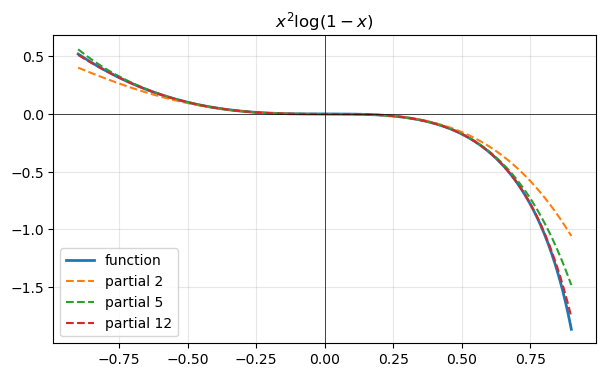

In [81]:
import math
import matplotlib.pyplot as plt

def exact(x):
    return x**2 * math.log1p(-x)


def partial(x, N):
    return -sum(x**(n + 2) / n for n in range(1, N + 1))

xs = [-0.9 + (0.9 - (-0.9)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [2, 5, 12]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$x^2\log(1-x)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-6"></a>

### Problem 6. Series for $x\sqrt{1+x}$

Using the binomial series,

$$
x\sqrt{1+x}=x(1+x)^{1/2}
=x\sum_{n=0}^{\infty}\binom{1/2}{n}x^n.
$$

So

$$
x\sqrt{1+x}=x+\frac{x^2}{2}-\frac{x^3}{8}+\frac{x^4}{16}
-\frac{5x^5}{128}+\cdots,
\qquad |x|<1.
$$


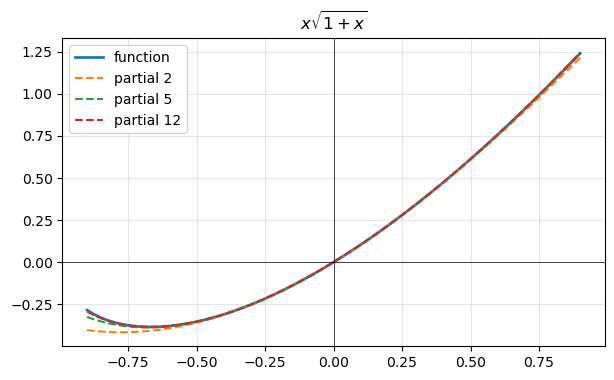

In [82]:
import math
import matplotlib.pyplot as plt

def binom(p, n):
    c = 1
    for k in range(n):
        c *= (p - k) / (k + 1)
    return c


def exact(x):
    return x * math.sqrt(1 + x)


def partial(x, N):
    return sum(binom(1/2, n) * x**(n + 1) for n in range(N + 1))

xs = [-0.9 + (0.9 - (-0.9)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [2, 5, 12]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$x\sqrt{1+x}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-7"></a>

### Problem 7. Series for $\sin x/x$

$$
\frac{\sin x}{x}
=\sum_{n=0}^{\infty}\frac{(-1)^n x^{2n}}{(2n+1)!}
=1-\frac{x^2}{3!}+\frac{x^4}{5!}-\frac{x^6}{7!}+\cdots.
$$

This series converges for all $x$.


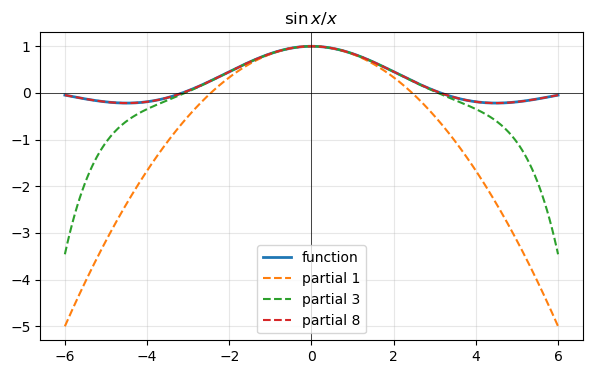

In [83]:
import math
import matplotlib.pyplot as plt

def exact(x):
    return 1 if x == 0 else math.sin(x) / x


def partial(x, N):
    return sum((-1)**n * x**(2*n) / math.factorial(2*n + 1) for n in range(N + 1))

xs = [-6 + (6 - (-6)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [1, 3, 8]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\sin x/x$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-8"></a>

### Problem 8. Series for $1/\sqrt{1-x^2}$

$$
\frac{1}{\sqrt{1-x^2}}
=(1-x^2)^{-1/2}
=\sum_{n=0}^{\infty}\frac{\binom{2n}{n}}{4^n}x^{2n}.
$$

So

$$
\frac{1}{\sqrt{1-x^2}}
=1+\frac{x^2}{2}+\frac{3x^4}{8}+\frac{5x^6}{16}+\cdots,
\qquad |x|<1.
$$


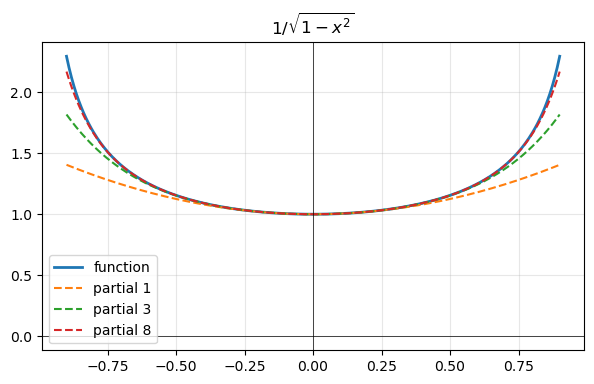

In [84]:
import math
import matplotlib.pyplot as plt

def exact(x):
    return 1 / math.sqrt(1 - x**2)


def partial(x, N):
    return sum(math.comb(2*n, n) * x**(2*n) / 4**n for n in range(N + 1))

xs = [-0.9 + (0.9 - (-0.9)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [1, 3, 8]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$1/\sqrt{1-x^2}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-9"></a>

### Problem 9. Series for $(1+x)/(1-x)$

$$
\frac{1+x}{1-x}=(1+x)\sum_{n=0}^{\infty}x^n
=1+2\sum_{n=1}^{\infty}x^n.
$$

Thus

$$
\frac{1+x}{1-x}=1+2x+2x^2+2x^3+\cdots,
\qquad |x|<1.
$$


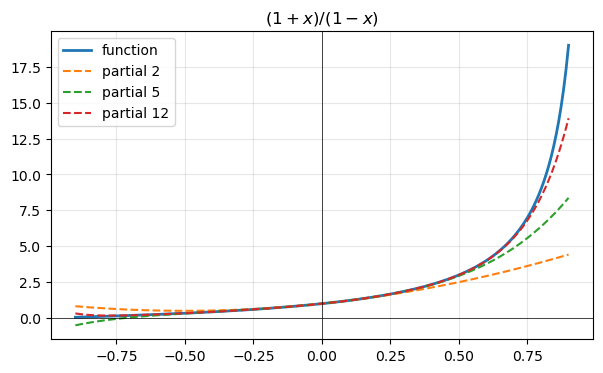

In [85]:
import math
import matplotlib.pyplot as plt

def exact(x):
    return (1 + x) / (1 - x)


def partial(x, N):
    return 1 + 2 * sum(x**n for n in range(1, N + 1))

xs = [-0.9 + (0.9 - (-0.9)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [2, 5, 12]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$(1+x)/(1-x)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-10"></a>

### Problem 10. Series for $\sin(x^2)$

Substitute $x^2$ into the sine series:

$$
\sin(x^2)
=\sum_{n=0}^{\infty}\frac{(-1)^n x^{4n+2}}{(2n+1)!}
=x^2-\frac{x^6}{3!}+\frac{x^{10}}{5!}-\cdots.
$$

This series converges for all $x$.


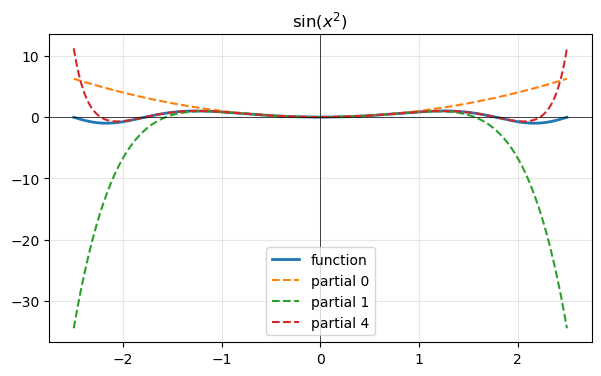

In [86]:
import math
import matplotlib.pyplot as plt

def exact(x):
    return math.sin(x**2)


def partial(x, N):
    return sum((-1)**n * x**(4*n + 2) / math.factorial(2*n + 1) for n in range(N + 1))

xs = [-2.5 + (2.5 - (-2.5)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [0, 1, 4]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\sin(x^2)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-11"></a>

### Problem 11. Series for $\sin\sqrt{x}/\sqrt{x}$

For $x>0$, substitute $\sqrt{x}$ into $\sin u/u$:

$$
\frac{\sin\sqrt{x}}{\sqrt{x}}
=\sum_{n=0}^{\infty}\frac{(-1)^n x^n}{(2n+1)!}
=1-\frac{x}{3!}+\frac{x^2}{5!}-\frac{x^3}{7!}+\cdots.
$$


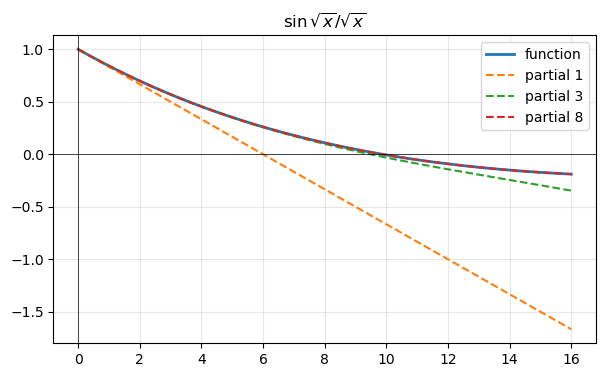

In [87]:
import math
import matplotlib.pyplot as plt

def exact(x):
    return 1 if x == 0 else math.sin(math.sqrt(x)) / math.sqrt(x)


def partial(x, N):
    return sum((-1)**n * x**n / math.factorial(2*n + 1) for n in range(N + 1))

xs = [0 + (16 - (0)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [1, 3, 8]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\sin\sqrt{x}/\sqrt{x}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-12"></a>

### Problem 12. Series for $\int_0^x \cos(t^2)\,dt$

$$
\cos(t^2)=\sum_{n=0}^{\infty}\frac{(-1)^n t^{4n}}{(2n)!}.
$$

Integrating term by term,

$$
\int_0^x \cos(t^2)\,dt
=\sum_{n=0}^{\infty}\frac{(-1)^n x^{4n+1}}{(2n)!(4n+1)}
=x-\frac{x^5}{10}+\frac{x^9}{216}-\cdots.
$$


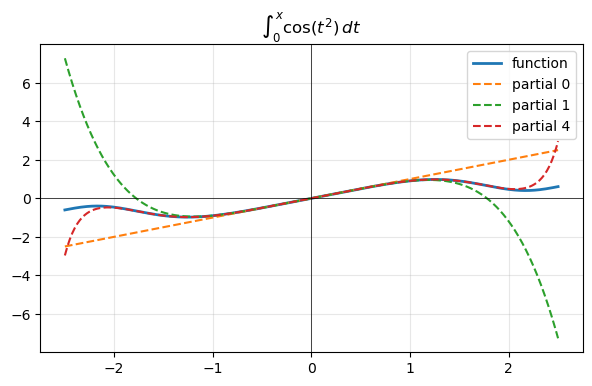

In [88]:
import math
import matplotlib.pyplot as plt

def integral(f, a, b, n=600):
    if b < a:
        return -integral(f, b, a, n)
    h = (b - a) / n
    odd = sum(f(a + (2*k - 1)*h) for k in range(1, n//2 + 1))
    even = sum(f(a + 2*k*h) for k in range(1, n//2))
    return h/3 * (f(a) + f(b) + 4*odd + 2*even)

def exact(x):
    return integral(lambda t: math.cos(t**2), 0, x)


def partial(x, N):
    return sum((-1)**n * x**(4*n + 1) / (math.factorial(2*n) * (4*n + 1)) for n in range(N + 1))

xs = [-2.5 + (2.5 - (-2.5)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [0, 1, 4]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\int_0^x \cos(t^2)\,dt$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-13"></a>

### Problem 13. Series for $\int_0^x e^{-t^2}\,dt$

$$
e^{-t^2}=\sum_{n=0}^{\infty}\frac{(-1)^n t^{2n}}{n!}.
$$

Therefore

$$
\int_0^x e^{-t^2}\,dt
=\sum_{n=0}^{\infty}\frac{(-1)^n x^{2n+1}}{n!(2n+1)}
=x-\frac{x^3}{3}+\frac{x^5}{10}-\frac{x^7}{42}+\cdots.
$$


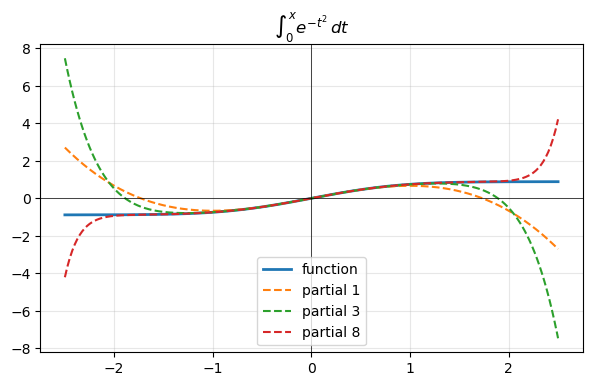

In [89]:
import math
import matplotlib.pyplot as plt

def integral(f, a, b, n=600):
    if b < a:
        return -integral(f, b, a, n)
    h = (b - a) / n
    odd = sum(f(a + (2*k - 1)*h) for k in range(1, n//2 + 1))
    even = sum(f(a + 2*k*h) for k in range(1, n//2))
    return h/3 * (f(a) + f(b) + 4*odd + 2*even)

def exact(x):
    return integral(lambda t: math.exp(-t**2), 0, x)


def partial(x, N):
    return sum((-1)**n * x**(2*n + 1) / (math.factorial(n) * (2*n + 1)) for n in range(N + 1))

xs = [-2.5 + (2.5 - (-2.5)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [1, 3, 8]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\int_0^x e^{-t^2}\,dt$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-14"></a>

### Problem 14. Series for $\ln\sqrt{(1+x)/(1-x)}$

Since

$$
\ln\sqrt{\frac{1+x}{1-x}}=\frac{1}{2}\ln\frac{1+x}{1-x},
$$

and

$$
\int_0^x\frac{dt}{1-t^2}=\int_0^x\sum_{n=0}^{\infty}t^{2n}\,dt,
$$

we get

$$
\ln\sqrt{\frac{1+x}{1-x}}
=\sum_{n=0}^{\infty}\frac{x^{2n+1}}{2n+1}
=x+\frac{x^3}{3}+\frac{x^5}{5}+\cdots,
\qquad |x|<1.
$$


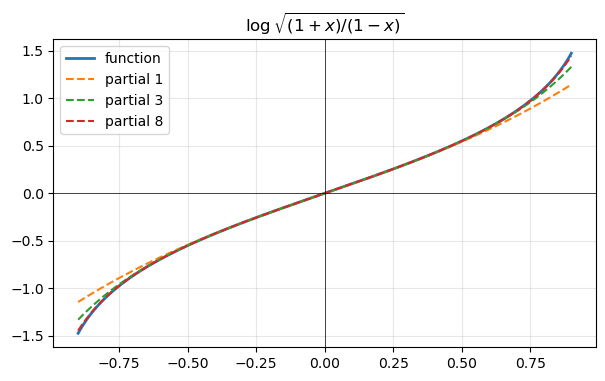

In [90]:
import math
import matplotlib.pyplot as plt

def exact(x):
    return 0.5 * math.log((1 + x) / (1 - x))


def partial(x, N):
    return sum(x**(2*n + 1) / (2*n + 1) for n in range(N + 1))

xs = [-0.9 + (0.9 - (-0.9)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [1, 3, 8]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\log\sqrt{(1+x)/(1-x)}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-15"></a>

### Problem 15. Series for $\arcsin x$

Using [Problem 8](#problem-8),

$$
\frac{1}{\sqrt{1-t^2}}
=\sum_{n=0}^{\infty}\frac{\binom{2n}{n}}{4^n}t^{2n}.
$$

Thus

$$
\arcsin x
=\sum_{n=0}^{\infty}\frac{\binom{2n}{n}}{4^n(2n+1)}x^{2n+1}
=x+\frac{x^3}{6}+\frac{3x^5}{40}+\frac{5x^7}{112}+\cdots.
$$


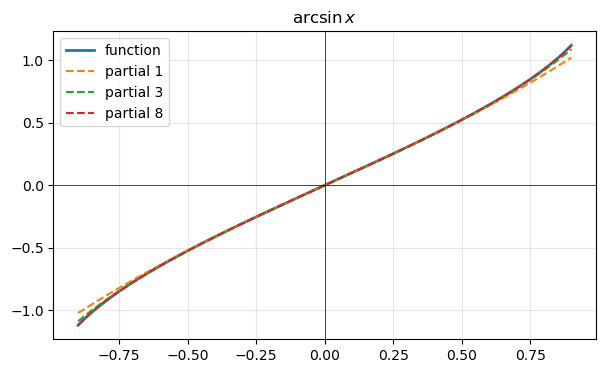

In [91]:
import math
import matplotlib.pyplot as plt

def exact(x):
    return math.asin(x)


def partial(x, N):
    return sum(math.comb(2*n, n) * x**(2*n + 1) / (4**n * (2*n + 1)) for n in range(N + 1))

xs = [-0.9 + (0.9 - (-0.9)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [1, 3, 8]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\arcsin x$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-16"></a>

### Problem 16. Series for $\cosh x$

$$
\cosh x=\frac{e^x+e^{-x}}{2}
=\sum_{n=0}^{\infty}\frac{x^{2n}}{(2n)!}
=1+\frac{x^2}{2!}+\frac{x^4}{4!}+\frac{x^6}{6!}+\cdots.
$$

This series converges for all $x$.


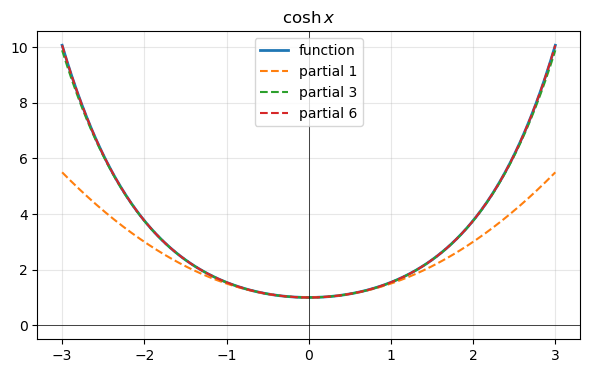

In [92]:
import math
import matplotlib.pyplot as plt

def exact(x):
    return math.cosh(x)


def partial(x, N):
    return sum(x**(2*n) / math.factorial(2*n) for n in range(N + 1))

xs = [-3 + (3 - (-3)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [1, 3, 6]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\cosh x$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-17"></a>

### Problem 17. Series for $\ln((1+x)/(1-x))$

Twice [Problem 14](#problem-14) gives

$$
\ln\frac{1+x}{1-x}
=2\sum_{n=0}^{\infty}\frac{x^{2n+1}}{2n+1}
=2x+\frac{2x^3}{3}+\frac{2x^5}{5}+\cdots,
\qquad |x|<1.
$$


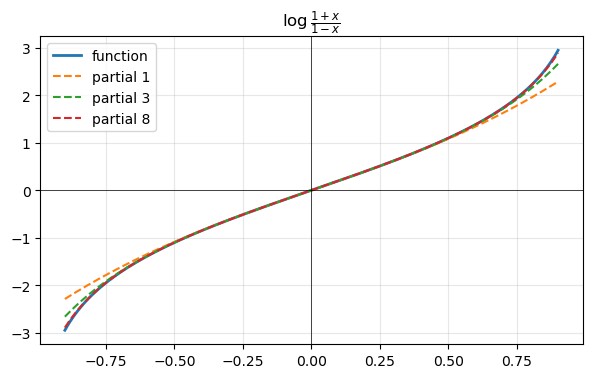

In [93]:
import math
import matplotlib.pyplot as plt

def exact(x):
    return math.log((1 + x) / (1 - x))


def partial(x, N):
    return 2 * sum(x**(2*n + 1) / (2*n + 1) for n in range(N + 1))

xs = [-0.9 + (0.9 - (-0.9)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [1, 3, 8]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\log\frac{1+x}{1-x}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-18"></a>

### Problem 18. Series for $\int_0^x (\sin t)/t\,dt$

$$
\frac{\sin t}{t}
=\sum_{n=0}^{\infty}\frac{(-1)^n t^{2n}}{(2n+1)!}.
$$

Therefore

$$
\int_0^x \frac{\sin t}{t}\,dt
=\sum_{n=0}^{\infty}\frac{(-1)^n x^{2n+1}}{(2n+1)(2n+1)!}
=x-\frac{x^3}{18}+\frac{x^5}{600}-\cdots.
$$


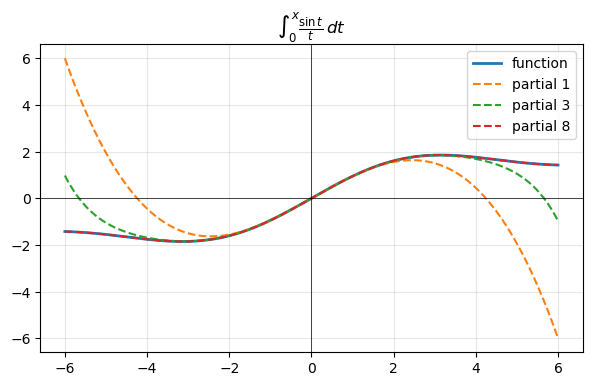

In [94]:
import math
import matplotlib.pyplot as plt

def integral(f, a, b, n=600):
    if b < a:
        return -integral(f, b, a, n)
    h = (b - a) / n
    odd = sum(f(a + (2*k - 1)*h) for k in range(1, n//2 + 1))
    even = sum(f(a + 2*k*h) for k in range(1, n//2))
    return h/3 * (f(a) + f(b) + 4*odd + 2*even)

def sinc(x):
    return 1 if x == 0 else math.sin(x) / x


def exact(x):
    return integral(sinc, 0, x)


def partial(x, N):
    return sum((-1)**n * x**(2*n + 1) / ((2*n + 1) * math.factorial(2*n + 1)) for n in range(N + 1))

xs = [-6 + (6 - (-6)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [1, 3, 8]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\int_0^x \frac{\sin t}{t}\,dt$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-19"></a>

### Problem 19. Series for $\ln(x+\sqrt{1+x^2})$

$$
\ln(x+\sqrt{1+x^2})=\int_0^x\frac{dt}{\sqrt{1+t^2}}.
$$

Since

$$
(1+t^2)^{-1/2}=\sum_{n=0}^{\infty}(-1)^n\frac{\binom{2n}{n}}{4^n}t^{2n},
$$

we have

$$
\ln(x+\sqrt{1+x^2})
=\sum_{n=0}^{\infty}(-1)^n\frac{\binom{2n}{n}}{4^n(2n+1)}x^{2n+1}
=x-\frac{x^3}{6}+\frac{3x^5}{40}-\frac{5x^7}{112}+\cdots.
$$


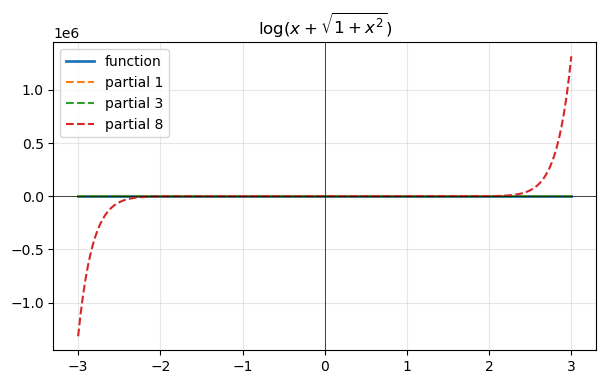

In [95]:
import math
import matplotlib.pyplot as plt

def exact(x):
    return math.asinh(x)


def partial(x, N):
    return sum((-1)**n * math.comb(2*n, n) * x**(2*n + 1) / (4**n * (2*n + 1)) for n in range(N + 1))

xs = [-3 + (3 - (-3)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [1, 3, 8]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\log(x+\sqrt{1+x^2})$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-20"></a>

### Problem 20. Series for $e^x\sin x$

$$
e^x\sin x=x+x^2+\frac{x^3}{3}-\frac{x^5}{30}-\frac{x^6}{90}-\frac{x^7}{630}+\cdots.
$$


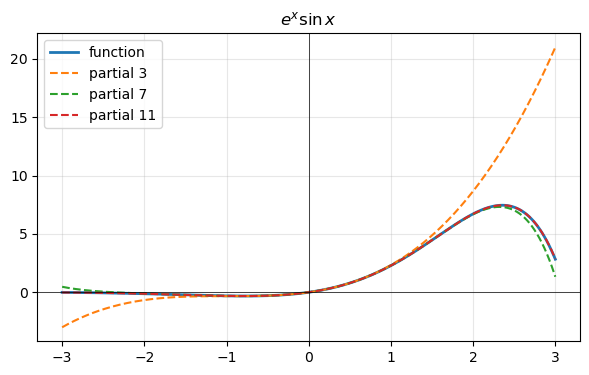

In [96]:
import math
import matplotlib.pyplot as plt

def exact(x):
    return math.exp(x) * math.sin(x)


def partial(x, N):
    return sum((((1 + 1j)**n).imag / math.factorial(n)) * x**n for n in range(1, N + 1))

xs = [-3 + (3 - (-3)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [3, 7, 11]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$e^x\sin x$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-21"></a>

### Problem 21. Series for $\tan^2 x$

$$
\tan^2 x=x^2+\frac{2x^4}{3}+\frac{17x^6}{45}+\frac{62x^8}{315}+\cdots.
$$


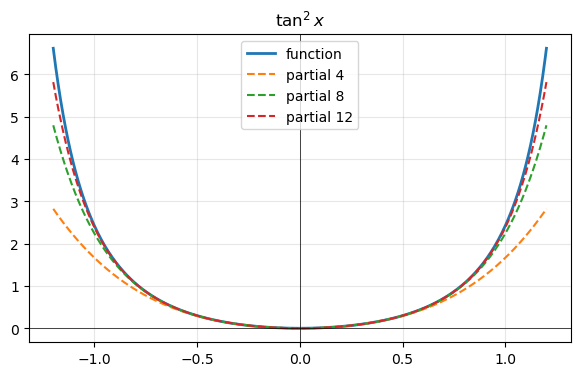

In [97]:
import math
import matplotlib.pyplot as plt

coeffs = {2: 1, 4: 2/3, 6: 17/45, 8: 62/315, 10: 1_382/14_175, 12: 21_844/467_775}


def exact(x):
    return math.tan(x)**2


def partial(x, N):
    return sum(c * x**p for p, c in coeffs.items() if p <= N)

xs = [-1.2 + (1.2 - (-1.2)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [4, 8, 12]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\tan^2 x$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-22"></a>

### Problem 22. Series for $e^x/(1-x)$

$$
\frac{e^x}{1-x}=1+2x+\frac{5x^2}{2}+\frac{8x^3}{3}+\frac{65x^4}{24}+\cdots.
$$


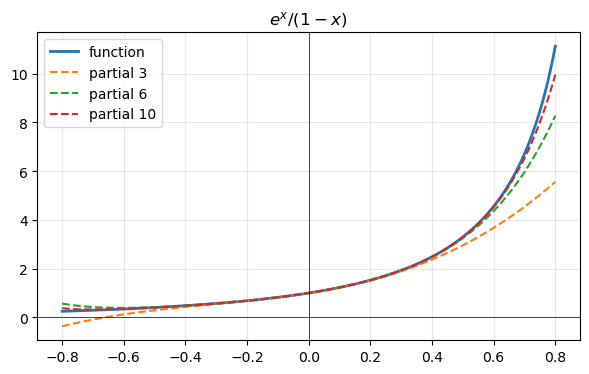

In [98]:
import math
import matplotlib.pyplot as plt

def exact(x):
    return math.exp(x) / (1 - x)


def partial(x, N):
    return sum(sum(1 / math.factorial(k) for k in range(n + 1)) * x**n for n in range(N + 1))

xs = [-0.8 + (0.8 - (-0.8)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [3, 6, 10]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$e^x/(1-x)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-23"></a>

### Problem 23. Series for $1/(1+x+x^2)$

Since $1+x+x^2=(1-x^3)/(1-x)$,

$$
\frac{1}{1+x+x^2}=\frac{1-x}{1-x^3}
=1-x+x^3-x^4+x^6-x^7+\cdots.
$$


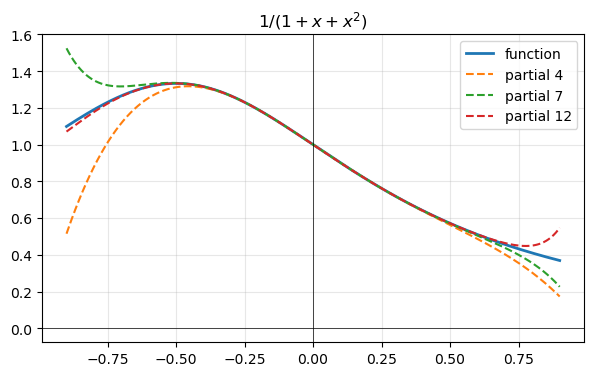

In [99]:
import math
import matplotlib.pyplot as plt

def exact(x):
    return 1 / (1 + x + x**2)


def partial(x, N):
    return sum((1 if n % 3 == 0 else -1 if n % 3 == 1 else 0) * x**n for n in range(N + 1))

xs = [-0.9 + (0.9 - (-0.9)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [4, 7, 12]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$1/(1+x+x^2)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-24"></a>

### Problem 24. Series for $\sec x$

$$
\sec x=1+\frac{x^2}{2}+\frac{5x^4}{24}+\frac{61x^6}{720}+\frac{277x^8}{8064}+\cdots.
$$


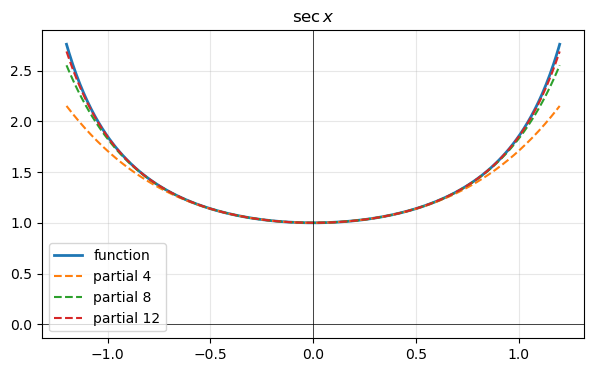

In [100]:
import math
import matplotlib.pyplot as plt

coeffs = {0: 1, 2: 1/2, 4: 5/24, 6: 61/720, 8: 277/8_064, 10: 50_521/3_628_800, 12: 540_553/95_800_320}


def exact(x):
    return 1 / math.cos(x)


def partial(x, N):
    return sum(c * x**p for p, c in coeffs.items() if p <= N)

xs = [-1.2 + (1.2 - (-1.2)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [4, 8, 12]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\sec x$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-25"></a>

### Problem 25. Series for $2x/(e^{2x}-1)$

$$
\frac{2x}{e^{2x}-1}
=1-x+\frac{x^2}{3}-\frac{x^4}{45}+\frac{2x^6}{945}-\cdots.
$$


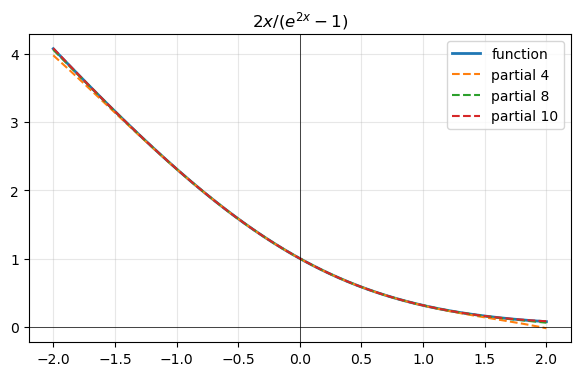

In [101]:
import math
import matplotlib.pyplot as plt

coeffs = {0: 1, 1: -1, 2: 1/3, 4: -1/45, 6: 2/945, 8: -1/4_725, 10: 2/93_555}


def exact(x):
    return 1 if x == 0 else 2*x / (math.exp(2*x) - 1)


def partial(x, N):
    return sum(c * x**p for p, c in coeffs.items() if p <= N)

xs = [-2 + (2 - (-2)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [4, 8, 10]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$2x/(e^{2x}-1)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-26"></a>

### Problem 26. Series for $1/\sqrt{\cos x}$

$$
\frac{1}{\sqrt{\cos x}}
=1+\frac{x^2}{4}+\frac{7x^4}{96}+\frac{139x^6}{5760}+\frac{5473x^8}{645120}+\cdots.
$$


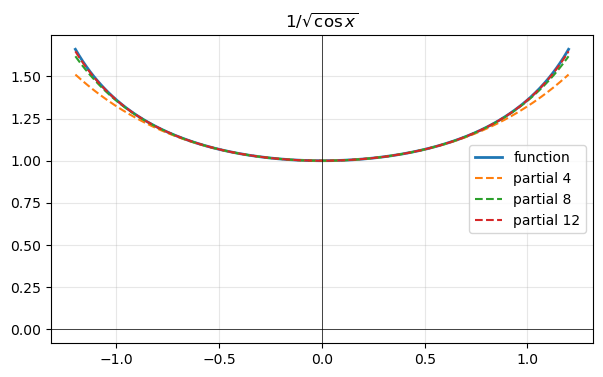

In [102]:
import math
import matplotlib.pyplot as plt

coeffs = {0: 1, 2: 1/4, 4: 7/96, 6: 139/5_760, 8: 5_473/645_120, 10: 51_103/16_588_800, 12: 34_988_647/30_656_102_400}


def exact(x):
    return 1 / math.sqrt(math.cos(x))


def partial(x, N):
    return sum(c * x**p for p, c in coeffs.items() if p <= N)

xs = [-1.2 + (1.2 - (-1.2)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [4, 8, 12]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$1/\sqrt{\cos x}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-27"></a>

### Problem 27. Series for $e^{\sin x}$

$$
e^{\sin x}=1+x+\frac{x^2}{2}-\frac{x^4}{8}-\frac{x^5}{15}-\frac{x^6}{240}+\cdots.
$$


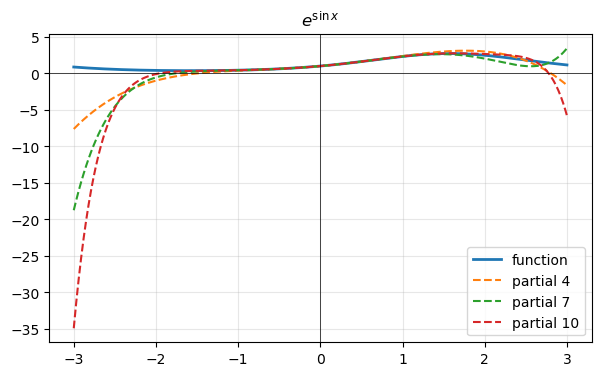

In [103]:
import math
import matplotlib.pyplot as plt

coeffs = {0: 1, 1: 1, 2: 1/2, 4: -1/8, 5: -1/15, 6: -1/240, 7: 1/90, 8: 31/5_760, 9: 1/5_670, 10: -2_951/3_628_800}


def exact(x):
    return math.exp(math.sin(x))


def partial(x, N):
    return sum(c * x**p for p, c in coeffs.items() if p <= N)

xs = [-3 + (3 - (-3)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [4, 7, 10]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$e^{\sin x}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-28"></a>

### Problem 28. Series for $\sin[\ln(1+x)]$

$$
\sin[\ln(1+x)]
=x-\frac{x^2}{2}+\frac{x^3}{6}-\frac{x^5}{12}+\frac{x^6}{8}-\frac{73x^7}{504}+\cdots.
$$


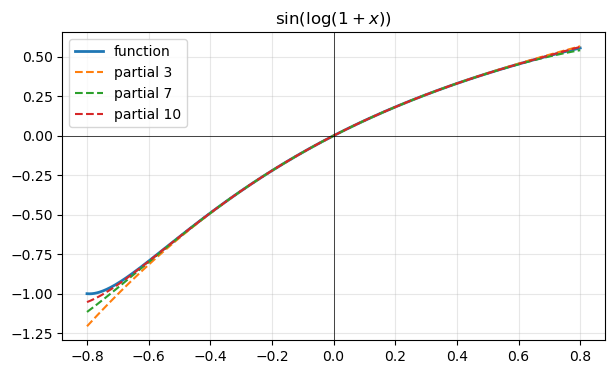

In [104]:
import math
import matplotlib.pyplot as plt

coeffs = {1: 1, 2: -1/2, 3: 1/6, 5: -1/12, 6: 1/8, 7: -73/504, 8: 11/72, 9: -2_795/18_144, 10: 611/4_032}


def exact(x):
    return math.sin(math.log1p(x))


def partial(x, N):
    return sum(c * x**p for p, c in coeffs.items() if p <= N)

xs = [-0.8 + (0.8 - (-0.8)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [3, 7, 10]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\sin(\log(1+x))$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-29"></a>

### Problem 29. Series for $\sqrt{1+\ln(1+x)}$

$$
\sqrt{1+\ln(1+x)}
=1+\frac{x}{2}-\frac{3x^2}{8}+\frac{17x^3}{48}-\frac{143x^4}{384}+\cdots.
$$


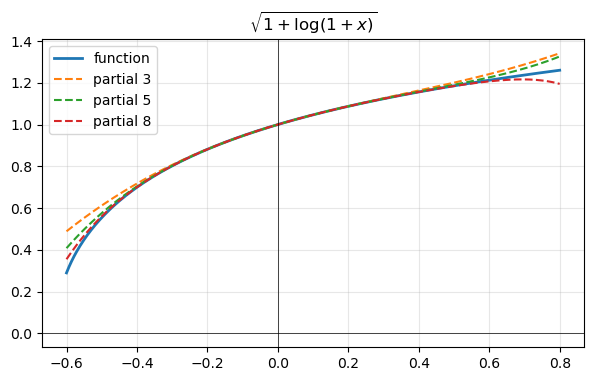

In [105]:
import math
import matplotlib.pyplot as plt

coeffs = {0: 1, 1: 1/2, 2: -3/8, 3: 17/48, 4: -143/384, 5: 1_609/3_840, 6: -22_819/46_080, 7: 8_717/14_336, 8: -2_649_173/3_440_640}


def exact(x):
    return math.sqrt(1 + math.log1p(x))


def partial(x, N):
    return sum(c * x**p for p, c in coeffs.items() if p <= N)

xs = [-0.6 + (0.8 - (-0.6)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [3, 5, 8]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\sqrt{1+\log(1+x)}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-30"></a>

### Problem 30. Series for $\sqrt{(1-x)/(1+x)}$

$$
\sqrt{\frac{1-x}{1+x}}
=1-x+\frac{x^2}{2}-\frac{x^3}{2}+\frac{3x^4}{8}-\frac{3x^5}{8}+\cdots.
$$


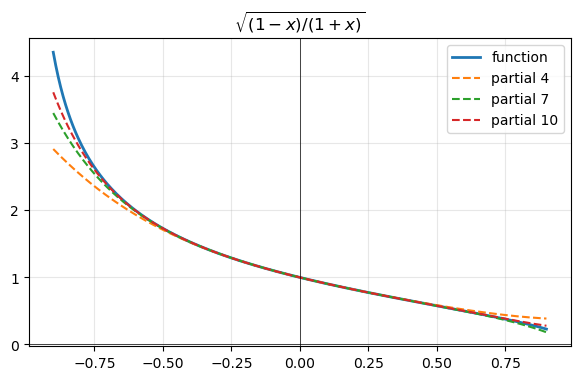

In [106]:
import math
import matplotlib.pyplot as plt

coeffs = {0: 1, 1: -1, 2: 1/2, 3: -1/2, 4: 3/8, 5: -3/8, 6: 5/16, 7: -5/16, 8: 35/128, 9: -35/128, 10: 63/256}


def exact(x):
    return math.sqrt((1 - x) / (1 + x))


def partial(x, N):
    return sum(c * x**p for p, c in coeffs.items() if p <= N)

xs = [-0.9 + (0.9 - (-0.9)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [4, 7, 10]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\sqrt{(1-x)/(1+x)}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-31"></a>

### Problem 31. Series for $\cos(e^x-1)$

$$
\cos(e^x-1)
=1-\frac{x^2}{2}-\frac{x^3}{2}-\frac{x^4}{4}-\frac{x^5}{24}+\frac{11x^6}{240}+\cdots.
$$


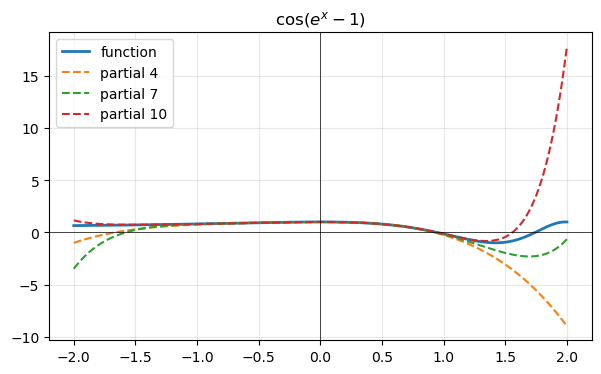

In [107]:
import math
import matplotlib.pyplot as plt

coeffs = {0: 1, 2: -1/2, 3: -1/2, 4: -1/4, 5: -1/24, 6: 11/240, 7: 19/360, 8: 187/5_760, 9: 109/8_064, 10: 7_199/2_268_000}


def exact(x):
    return math.cos(math.exp(x) - 1)


def partial(x, N):
    return sum(c * x**p for p, c in coeffs.items() if p <= N)

xs = [-2 + (2 - (-2)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [4, 7, 10]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\cos(e^x-1)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-32"></a>

### Problem 32. Series for $\ln(1+xe^x)$

$$
\ln(1+xe^x)
=x+\frac{x^2}{2}-\frac{x^3}{6}-\frac{x^4}{12}+\frac{3x^5}{40}+\cdots.
$$


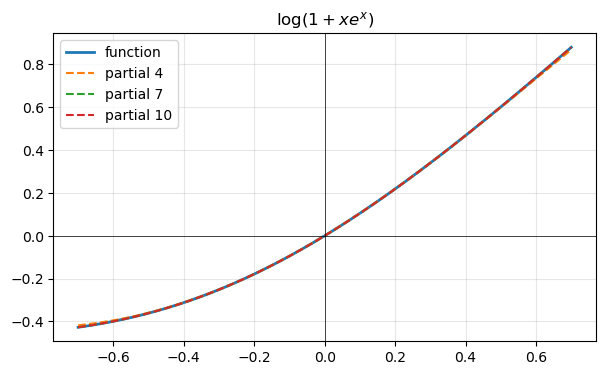

In [108]:
import math
import matplotlib.pyplot as plt

coeffs = {1: 1, 2: 1/2, 3: -1/6, 4: -1/12, 5: 3/40, 6: 1/120, 7: -31/1_008, 8: 29/5_040, 9: 7/640, 10: -26_087/4_536_000}


def exact(x):
    return math.log1p(x * math.exp(x))


def partial(x, N):
    return sum(c * x**p for p, c in coeffs.items() if p <= N)

xs = [-0.7 + (0.7 - (-0.7)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [4, 7, 10]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\log(1+xe^x)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-33"></a>

### Problem 33. Series for $(1-\sin x)/(1-x)$

$$
\frac{1-\sin x}{1-x}
=1+\frac{x^3}{6}+\frac{x^4}{6}+\frac{19x^5}{120}+\frac{19x^6}{120}+\cdots.
$$


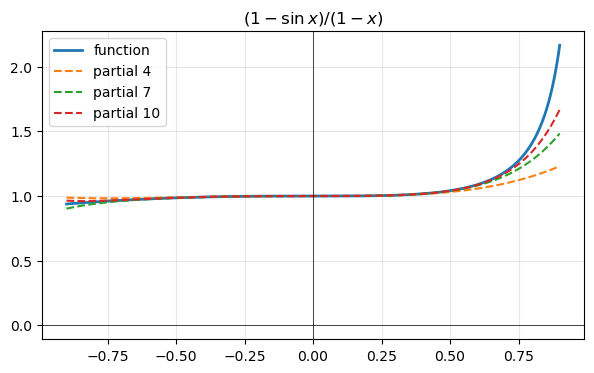

In [109]:
import math
import matplotlib.pyplot as plt

coeffs = {0: 1, 3: 1/6, 4: 1/6, 5: 19/120, 6: 19/120, 7: 799/5_040, 8: 799/5_040, 9: 57_527/362_880, 10: 57_527/362_880}


def exact(x):
    return (1 - math.sin(x)) / (1 - x)


def partial(x, N):
    return sum(c * x**p for p, c in coeffs.items() if p <= N)

xs = [-0.9 + (0.9 - (-0.9)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [4, 7, 10]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$(1-\sin x)/(1-x)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-34"></a>

### Problem 34. Series for $\ln(2-e^{-x})$

$$
\ln(2-e^{-x})
=x-x^2+x^3-\frac{13x^4}{12}+\frac{5x^5}{4}-\frac{541x^6}{360}+\cdots.
$$


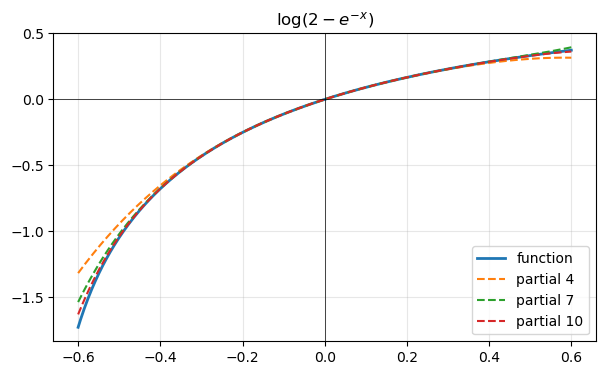

In [110]:
import math
import matplotlib.pyplot as plt

coeffs = {1: 1, 2: -1, 3: 1, 4: -13/12, 5: 5/4, 6: -541/360, 7: 223/120, 8: -9_457/4_032, 9: 109_201/36_288, 10: -3_548_771/907_200}


def exact(x):
    return math.log(2 - math.exp(-x))


def partial(x, N):
    return sum(c * x**p for p, c in coeffs.items() if p <= N)

xs = [-0.6 + (0.6 - (-0.6)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [4, 7, 10]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\log(2-e^{-x})$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-35"></a>

### Problem 35. Series for $x/\sin x$

$$
\frac{x}{\sin x}
=1+\frac{x^2}{6}+\frac{7x^4}{360}+\frac{31x^6}{15120}+\frac{127x^8}{604800}+\cdots.
$$


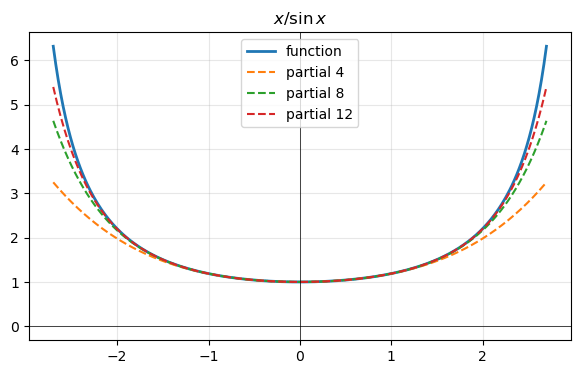

In [111]:
import math
import matplotlib.pyplot as plt

coeffs = {0: 1, 2: 1/6, 4: 7/360, 6: 31/15_120, 8: 127/604_800, 10: 73/3_421_440, 12: 1_414_477/653_837_184_000}


def exact(x):
    return 1 if x == 0 else x / math.sin(x)


def partial(x, N):
    return sum(c * x**p for p, c in coeffs.items() if p <= N)

xs = [-2.7 + (2.7 - (-2.7)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [4, 8, 12]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$x/\sin x$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-36"></a>

### Problem 36. Series for $\int_0^u \sin x/\sqrt{1-x^2}\,dx$

Let the upper limit be $u$:

$$
\int_0^u \frac{\sin x}{\sqrt{1-x^2}}\,dx
=\frac{u^2}{2}+\frac{u^4}{12}+\frac{u^6}{20}+\frac{2u^8}{63}+\frac{727u^{10}}{32400}+\cdots.
$$


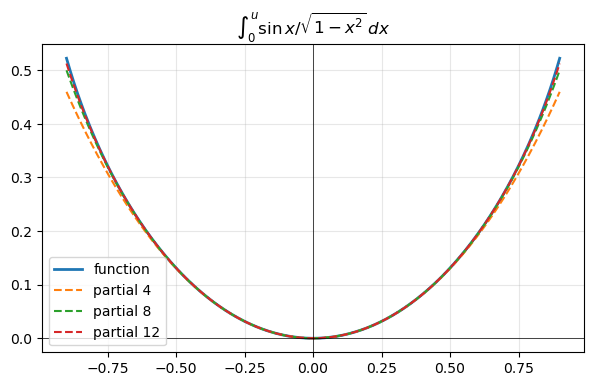

In [112]:
import math
import matplotlib.pyplot as plt

def integral(f, a, b, n=600):
    if b < a:
        return -integral(f, b, a, n)
    h = (b - a) / n
    odd = sum(f(a + (2*k - 1)*h) for k in range(1, n//2 + 1))
    even = sum(f(a + 2*k*h) for k in range(1, n//2))
    return h/3 * (f(a) + f(b) + 4*odd + 2*even)

coeffs = {2: 1/2, 4: 1/12, 6: 1/20, 8: 2/63, 10: 727/32_400, 12: 3_127/184_800}


def exact(u):
    return integral(lambda x: math.sin(x) / math.sqrt(1 - x**2), 0, u)


def partial(u, N):
    return sum(c * u**p for p, c in coeffs.items() if p <= N)

xs = [-0.9 + (0.9 - (-0.9)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [4, 8, 12]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\int_0^u \sin x/\sqrt{1-x^2}\,dx$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-37"></a>

### Problem 37. Series for $\ln(\cos x)$

Using $\ln(\cos x)=\ln(1+(\cos x-1))$,

$$
\ln(\cos x)
=-\frac{x^2}{2}-\frac{x^4}{12}-\frac{x^6}{45}-\frac{17x^8}{2520}-\cdots.
$$


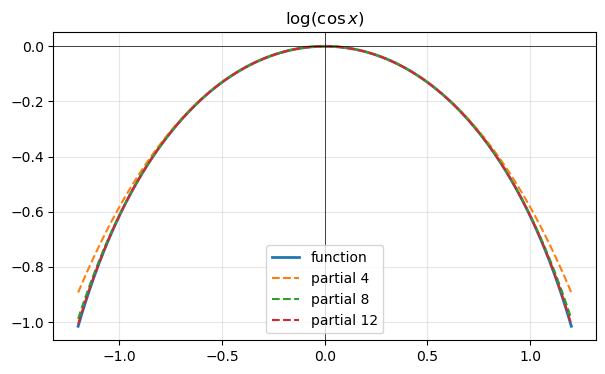

In [113]:
import math
import matplotlib.pyplot as plt

coeffs = {2: -1/2, 4: -1/12, 6: -1/45, 8: -17/2_520, 10: -31/14_175, 12: -691/935_550}


def exact(x):
    return math.log(math.cos(x))


def partial(x, N):
    return sum(c * x**p for p, c in coeffs.items() if p <= N)

xs = [-1.2 + (1.2 - (-1.2)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [4, 8, 12]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$\log(\cos x)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


<a id="problem-38"></a>

### Problem 38. Series for $e^{\cos x}$

Since $e^{\cos x}=e\,e^{\cos x-1}$,

$$
e^{\cos x}
=e\left(1-\frac{x^2}{2}+\frac{x^4}{6}-\frac{31x^6}{720}+\frac{379x^8}{40320}+\cdots\right).
$$


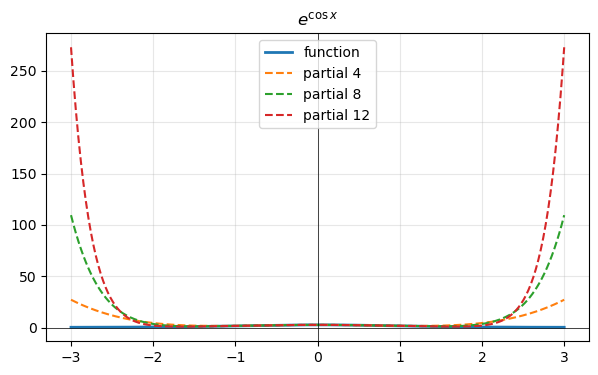

In [114]:
import math
import matplotlib.pyplot as plt

coeffs = {0: 1, 2: -1/2, 4: 1/6, 6: -31/720, 8: 379/40_320, 10: -1_639/907_200, 12: 150_349/479_001_600}


def exact(x):
    return math.exp(math.cos(x))


def partial(x, N):
    return math.e * sum(c * x**p for p, c in coeffs.items() if p <= N)

xs = [-3 + (3 - (-3)) * i / 400 for i in range(401)]

plt.figure(figsize=(7, 4))
plt.plot(xs, [exact(x) for x in xs], label="function", linewidth=2)
for N in [4, 8, 12]:
    plt.plot(xs, [partial(x, N) for x in xs], "--", label=f"partial {N}")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.title(r"$e^{\cos x}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## For Problems 39 through 44, use Taylor series about the specified point. Let $h=x-a$.


<a id="problem-39"></a>

### Problem 39. Taylor Series for $\sin x$ About $\pi/2$

For $f(x)=\sin x$, $a=\pi/2$. Put $h=x-\pi/2$. Then

$$
\sin x=\sin\left(\frac{\pi}{2}+h\right)=\cos h
=1-\frac{h^2}{2!}+\frac{h^4}{4!}-\frac{h^6}{6!}+\cdots.
$$

Therefore

$$
\sin x=1-\frac{(x-\pi/2)^2}{2!}+\frac{(x-\pi/2)^4}{4!}-\frac{(x-\pi/2)^6}{6!}+\cdots.
$$


In [115]:
import math


def partial(x, N=4):
    h = x - math.pi/2
    return sum((-1)**n * h**(2*n) / math.factorial(2*n) for n in range(N + 1))


x = 1.6
exact = math.sin(x)
approx = partial(x)
print("exact =", exact)
print("approx =", approx)
print("error =", approx - exact)


exact = 0.9995736030415051
approx = 0.9995736030415051
error = 0.0


<a id="problem-40"></a>

### Problem 40. Taylor Series for $1/x$ About $1$

For $f(x)=1/x$, $a=1$. Put $h=x-1$. Then

$$
\frac{1}{x}=\frac{1}{1+h}=\sum_{n=0}^{\infty}(-1)^n h^n.
$$

Thus

$$
\frac{1}{x}=1-(x-1)+(x-1)^2-(x-1)^3+\cdots,
\qquad |x-1|<1.
$$


In [116]:
import math


def partial(x, N=8):
    h = x - 1
    return sum((-1)**n * h**n for n in range(N + 1))


x = 1.1
exact = 1 / x
approx = partial(x)
print("exact =", exact)
print("approx =", approx)
print("error =", approx - exact)


exact = 0.9090909090909091
approx = 0.90909091
error = 9.090909136588721e-10


<a id="problem-41"></a>

### Problem 41. Taylor Series for $e^x$ About $3$

For $f(x)=e^x$, $a=3$. Put $h=x-3$. Then

$$
e^x=e^{3+h}=e^3e^h
=e^3\sum_{n=0}^{\infty}\frac{h^n}{n!}.
$$

So

$$
e^x=e^3\left[1+(x-3)+\frac{(x-3)^2}{2!}+\frac{(x-3)^3}{3!}+\cdots\right].
$$


In [117]:
import math


def partial(x, N=6):
    h = x - 3
    return math.e**3 * sum(h**n / math.factorial(n) for n in range(N + 1))


x = 3.1
exact = math.exp(x)
approx = partial(x)
print("exact =", exact)
print("approx =", approx)
print("error =", approx - exact)


exact = 22.197951281441636
approx = 22.19795128103807
error = -4.035669576296641e-10


<a id="problem-42"></a>

### Problem 42. Taylor Series for $\cos x$ About $\pi$

For $f(x)=\cos x$, $a=\pi$. Put $h=x-\pi$. Then

$$
\cos x=\cos(\pi+h)=-\cos h
=-1+\frac{h^2}{2!}-\frac{h^4}{4!}+\frac{h^6}{6!}-\cdots.
$$

Therefore

$$
\cos x=-1+\frac{(x-\pi)^2}{2!}-\frac{(x-\pi)^4}{4!}+\frac{(x-\pi)^6}{6!}-\cdots.
$$


In [118]:
import math


def partial(x, N=4):
    h = x - math.pi
    return -sum((-1)**n * h**(2*n) / math.factorial(2*n) for n in range(N + 1))


x = 3.2
exact = math.cos(x)
approx = partial(x)
print("exact =", exact)
print("approx =", approx)
print("error =", approx - exact)


exact = -0.9982947757947531
approx = -0.9982947757947531
error = 0.0


<a id="problem-43"></a>

### Problem 43. Taylor Series for $\cot x$ About $\pi/2$

For $f(x)=\cot x$, $a=\pi/2$. Put $h=x-\pi/2$. Since

$$
\cot\left(\frac{\pi}{2}+h\right)=-\tan h,
$$

we get

$$
\cot x=-(x-\pi/2)-\frac{(x-\pi/2)^3}{3}
-\frac{2(x-\pi/2)^5}{15}
-\frac{17(x-\pi/2)^7}{315}-\cdots.
$$


In [119]:
import math


def partial(x):
    h = x - math.pi/2
    return -h - h**3/3 - 2*h**5/15 - 17*h**7/315


x = 1.6
exact = 1 / math.tan(x)
approx = partial(x)
print("exact =", exact)
print("approx =", approx)
print("error =", approx - exact)


exact = -0.029211978199944887
approx = -0.029211978199944613
error = 2.740863092043355e-16


<a id="problem-44"></a>

### Problem 44. Taylor Series for $\sqrt{x}$ About $25$

For $f(x)=\sqrt{x}$, $a=25$. Put $h=x-25$. Then

$$
\sqrt{x}=\sqrt{25+h}=5\left(1+\frac{h}{25}\right)^{1/2}.
$$

Using the binomial series,

$$
\sqrt{x}
=5+\frac{x-25}{10}-\frac{(x-25)^2}{1000}
+\frac{(x-25)^3}{50000}
-\frac{(x-25)^4}{2000000}+\cdots.
$$


In [120]:
import math


def partial(x):
    h = x - 25
    return 5 + h/10 - h**2/1_000 + h**3/50_000 - h**4/2_000_000


x = 25.2
exact = math.sqrt(x)
approx = partial(x)
print("exact =", exact)
print("approx =", approx)
print("error =", approx - exact)


exact = 5.019960159204453
approx = 5.019960159199999
error = -4.454214774796128e-12
